# Upbit Basic Chart

티커, 시작 날짜, 끝 날짜, 분봉 간격을 입력하면 업비트 OHLCV 데이터를 가져와 캔들 차트와 거래량을 표시합니다.
원하면 `SHOW_RSI`를 `True`로 두고 RSI 30/70 기준선도 함께 볼 수 있습니다.


In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import pyupbit

ROOT_DIR = Path.cwd().resolve().parent if Path.cwd().name == 'backtesting' else Path.cwd().resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

plt.style.use('ggplot')
pd.set_option('display.max_rows', 10)


In [ ]:
TICKER = 'KRW-BTC'  # 업비트 마켓 티커
START_DATE = '2026-04-01 00:00:00'  # 차트에 표시할 시작 시각
END_DATE = '2026-05-08 00:00:00'  # 차트에 표시할 종료 시각
INTERVAL = 'minute60'  # 캔들 간격: minute1, minute5, minute15, minute60, day 등
REQUEST_COUNT = 200  # 업비트 API를 한 번 호출할 때 가져올 최대 캔들 수
SHOW_PRICE = True  # 가격 캔들 패널 표시 여부
SHOW_RSI = True  # RSI 패널 표시 여부
SHOW_VOLUME = False  # 거래량 패널 표시 여부
SHOW_PRICE_LOWER_MARKERS = True  # 가격 패널에 과매도 점 표시 여부
SHOW_PRICE_UPPER_MARKERS = True  # 가격 패널에 과매수 점 표시 여부
SHOW_PRICE_MARKER_COUNTS = True  # 가격 패널 우측 상단 점 개수 표시 여부
SHOW_RSI_LOWER_LINE = True  # RSI 하단 기준선 표시 여부
SHOW_RSI_UPPER_LINE = True  # RSI 상단 기준선 표시 여부
SHOW_RSI_LOWER_MARKERS = True  # RSI가 하단 기준선 이하일 때 점 표시 여부
SHOW_RSI_UPPER_MARKERS = True  # RSI가 상단 기준선 이상일 때 점 표시 여부
SHOW_RSI_MARKER_COUNTS = True  # RSI 패널 우측 상단 점 개수 표시 여부
RSI_PERIOD = 14  # RSI 계산 기간
RSI_LOWER = 30  # RSI 과매도 기준선
RSI_UPPER = 70  # RSI 과매수 기준선

# RSI가 시작일부터 자연스럽게 보이도록 여유 캔들을 미리 가져옵니다.
RSI_LOOKBACK_CANDLES = max(RSI_PERIOD * 2, 30)


def interval_to_timedelta(interval: str) -> pd.Timedelta:
    if interval.startswith('minute'):
        return pd.Timedelta(minutes=int(interval.replace('minute', '')))
    if interval == 'day':
        return pd.Timedelta(days=1)
    if interval == 'week':
        return pd.Timedelta(weeks=1)
    raise ValueError(f'Unsupported interval: {interval}')


def fetch_ohlcv_range(
    ticker: str,
    start_date: str,
    end_date: str,
    interval: str = 'minute60',
    request_count: int = 200,
    lookback_candles: int = 0,
) -> pd.DataFrame:
    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)
    if start_ts > end_ts:
        raise ValueError('START_DATE must be earlier than or equal to END_DATE.')

    step = interval_to_timedelta(interval)
    # 표시 시작일보다 더 앞에서부터 받아와야 RSI 초반값이 비지 않습니다.
    fetch_start_ts = start_ts - (step * lookback_candles)
    cursor = end_ts + step
    frames: list[pd.DataFrame] = []

    while True:
        df = pyupbit.get_ohlcv(
            ticker,
            interval=interval,
            count=request_count,
            to=cursor.strftime('%Y-%m-%d %H:%M:%S'),
        )
        if df is None or df.empty:
            break

        df = df.sort_index()
        frames.append(df)

        oldest = df.index.min()
        if oldest <= fetch_start_ts or len(df) < request_count:
            break

        cursor = oldest

    if not frames:
        raise ValueError(f'No OHLCV data returned for {ticker} ({interval}).')

    merged = pd.concat(frames).sort_index()
    merged = merged[~merged.index.duplicated(keep='last')]
    filtered = merged.loc[(merged.index >= fetch_start_ts) & (merged.index <= end_ts)].copy()

    if filtered.empty:
        raise ValueError('No candles found in the selected date range.')

    return filtered


def add_rsi(df: pd.DataFrame, period: int = 14) -> pd.DataFrame:
    result = df.copy()
    delta = result['close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, pd.NA)
    result['rsi'] = 100 - (100 / (1 + rs))
    return result


def plot_candles(
    df: pd.DataFrame,
    ticker: str,
    interval: str,
    show_price: bool = True,
    show_rsi: bool = False,
    show_volume: bool = True,
    show_price_lower_markers: bool = True,
    show_price_upper_markers: bool = True,
    show_price_marker_counts: bool = True,
    show_rsi_lower_line: bool = True,
    show_rsi_upper_line: bool = True,
    show_rsi_lower_markers: bool = True,
    show_rsi_upper_markers: bool = True,
    show_rsi_marker_counts: bool = True,
    rsi_period: int = 14,
    rsi_lower: float = 30,
    rsi_upper: float = 70,
    display_start_date: str | None = None,
    display_end_date: str | None = None,
) -> None:
    if not any([show_price, show_rsi, show_volume]):
        raise ValueError('At least one of SHOW_PRICE, SHOW_RSI, SHOW_VOLUME must be True.')

    # RSI는 전체 구간에서 먼저 계산한 뒤, 실제 표시 범위만 마지막에 잘라냅니다.
    chart_df = add_rsi(df, period=rsi_period).reset_index().rename(columns={'index': 'datetime'})

    if display_start_date is not None:
        chart_df = chart_df.loc[chart_df['datetime'] >= pd.Timestamp(display_start_date)]
    if display_end_date is not None:
        chart_df = chart_df.loc[chart_df['datetime'] <= pd.Timestamp(display_end_date)]
    if chart_df.empty:
        raise ValueError('No chart data left after applying the display date range.')

    # 날짜 필터 후 인덱스를 다시 0부터 맞춰야 x축 배열과 행 순서가 정확히 맞습니다.
    chart_df = chart_df.reset_index(drop=True)

    x = mdates.date2num(chart_df['datetime'].to_numpy())
    candle_width = max(0.0005, (x[1] - x[0]) * 0.7) if len(x) > 1 else 0.02

    lower_signal_points = chart_df.loc[chart_df['rsi'] <= rsi_lower]
    upper_signal_points = chart_df.loc[chart_df['rsi'] >= rsi_upper]

    panel_specs = []
    if show_price:
        panel_specs.append(('price', 3))
    if show_rsi:
        panel_specs.append(('rsi', 1))
    if show_volume:
        panel_specs.append(('volume', 1))

    fig, axes = plt.subplots(
        len(panel_specs),
        1,
        figsize=(16, 6 + len(panel_specs) * 1.5),
        sharex=True,
        gridspec_kw={'height_ratios': [ratio for _, ratio in panel_specs]},
    )

    if not isinstance(axes, (list, tuple)):
        axes = [axes] if getattr(axes, 'ndim', 0) == 0 else list(axes)

    axis_map = {name: axis for (name, _), axis in zip(panel_specs, axes)}
    ax_price = axis_map.get('price')
    ax_rsi = axis_map.get('rsi')
    ax_volume = axis_map.get('volume')

    for i, row in chart_df.iterrows():
        color = '#d62728' if row['close'] >= row['open'] else '#1f77b4'
        if ax_price is not None:
            ax_price.vlines(x[i], row['low'], row['high'], color=color, linewidth=1.0)
            body_bottom = min(row['open'], row['close'])
            body_height = abs(row['close'] - row['open'])
            if body_height == 0:
                body_height = max(row['close'] * 0.0005, 1e-6)
            ax_price.add_patch(
                Rectangle(
                    (x[i] - candle_width / 2, body_bottom),
                    candle_width,
                    body_height,
                    facecolor=color,
                    edgecolor=color,
                    alpha=0.85,
                )
            )
        if ax_volume is not None:
            ax_volume.bar(x[i], row['volume'], width=candle_width, color=color, alpha=0.35)

    if ax_price is not None:
        if show_price_lower_markers:
            ax_price.scatter(lower_signal_points['datetime'], lower_signal_points['close'], color='#1f77b4', s=18, zorder=3)
        if show_price_upper_markers:
            ax_price.scatter(upper_signal_points['datetime'], upper_signal_points['close'], color='#d62728', s=18, zorder=3)
        if show_price_marker_counts and (show_price_lower_markers or show_price_upper_markers):
            blue_count = len(lower_signal_points) if show_price_lower_markers else 0
            red_count = len(upper_signal_points) if show_price_upper_markers else 0
            ax_price.text(
                0.995,
                0.98,
                f'Blue: {blue_count} | Red: {red_count}',
                transform=ax_price.transAxes,
                ha='right',
                va='top',
                fontsize=10,
                bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'},
            )
        ax_price.set_title(f'{ticker} {interval} Chart')
        ax_price.set_ylabel('Price (KRW)')
        ax_price.grid(True, alpha=0.3)

    if ax_rsi is not None:
        ax_rsi.plot(chart_df['datetime'], chart_df['rsi'], color='#ff7f0e', linewidth=1.4)
        if show_rsi_lower_line:
            ax_rsi.axhline(rsi_lower, color='#2ca02c', linestyle='--', linewidth=1.0)
        if show_rsi_upper_line:
            ax_rsi.axhline(rsi_upper, color='#d62728', linestyle='--', linewidth=1.0)

        lower_points = lower_signal_points if show_rsi_lower_markers else chart_df.iloc[0:0]
        upper_points = upper_signal_points if show_rsi_upper_markers else chart_df.iloc[0:0]

        if show_rsi_lower_markers:
            ax_rsi.scatter(lower_points['datetime'], lower_points['rsi'], color='#1f77b4', s=18, zorder=3)

        if show_rsi_upper_markers:
            ax_rsi.scatter(upper_points['datetime'], upper_points['rsi'], color='#d62728', s=18, zorder=3)

        if show_rsi_marker_counts and (show_rsi_lower_markers or show_rsi_upper_markers):
            blue_count = len(lower_points) if show_rsi_lower_markers else 0
            red_count = len(upper_points) if show_rsi_upper_markers else 0
            ax_rsi.text(
                0.995,
                0.98,
                f'Blue: {blue_count} | Red: {red_count}',
                transform=ax_rsi.transAxes,
                ha='right',
                va='top',
                fontsize=10,
                bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'},
            )

        ax_rsi.set_ylabel('RSI')
        ax_rsi.set_ylim(0, 100)
        ax_rsi.grid(True, alpha=0.2)

    if ax_volume is not None:
        ax_volume.set_ylabel('Volume')
        ax_volume.grid(True, alpha=0.2)

    bottom_axis = axes[-1]
    bottom_axis.set_xlabel('Datetime')
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    bottom_axis.xaxis.set_major_locator(locator)
    bottom_axis.xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.show()


,open,high,low,close,volume,value
2026-05-07 20:00:00,118858000.0,119141000.0,118800000.0,118841000.0,38.794900,4.614021e+09
2026-05-07 21:00:00,118870000.0,119193000.0,118837000.0,119138000.0,40.791206,4.855186e+09
2026-05-07 22:00:00,119139000.0,119155000.0,118200000.0,118552000.0,128.489332,1.523449e+10
2026-05-07 23:00:00,118525000.0,118620000.0,118000000.0,118048000.0,111.968604,1.323868e+10
2026-05-08 00:00:00,118050000.0,118196000.0,117580000.0,117763000.0,138.533816,1.633073e+10


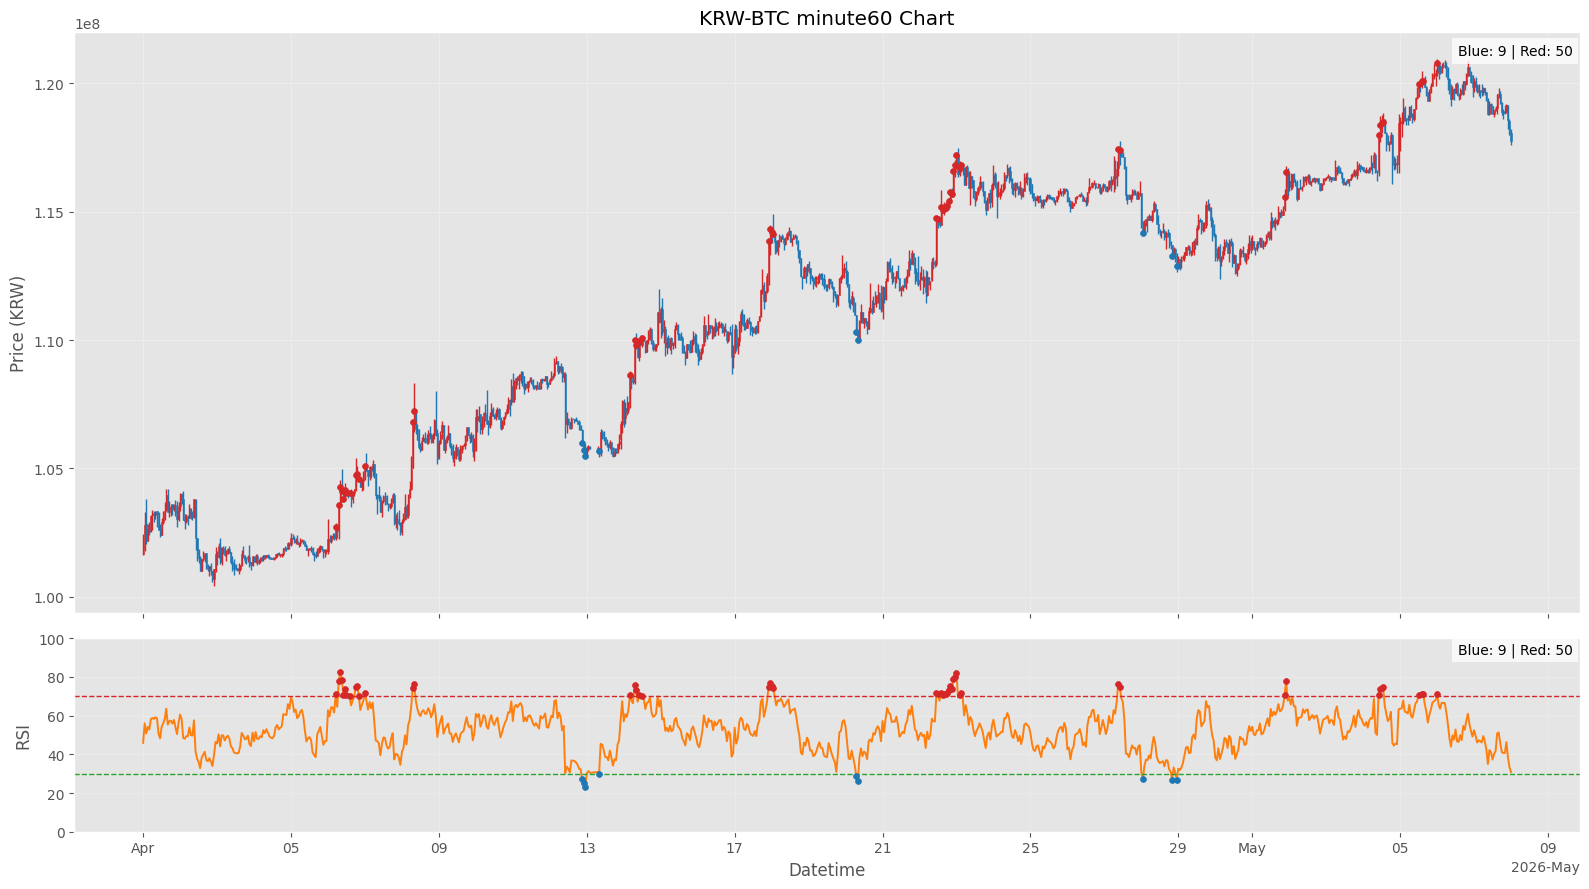

In [ ]:
# RSI 계산용 여유 데이터를 포함해서 먼저 조회합니다.
ohlcv_df = fetch_ohlcv_range(
    ticker=TICKER,
    start_date=START_DATE,
    end_date=END_DATE,
    interval=INTERVAL,
    request_count=REQUEST_COUNT,
    lookback_candles=RSI_LOOKBACK_CANDLES if SHOW_RSI else 0,
)

# 표는 사용자가 요청한 실제 표시 구간만 보여줍니다.
display_df = ohlcv_df.loc[(ohlcv_df.index >= pd.Timestamp(START_DATE)) & (ohlcv_df.index <= pd.Timestamp(END_DATE))].copy()
display(display_df.tail())
plot_candles(
    ohlcv_df,
    ticker=TICKER,
    interval=INTERVAL,
    show_price=SHOW_PRICE,
    show_rsi=SHOW_RSI,
    show_volume=SHOW_VOLUME,
    show_price_lower_markers=SHOW_PRICE_LOWER_MARKERS if SHOW_PRICE else False,
    show_price_upper_markers=SHOW_PRICE_UPPER_MARKERS if SHOW_PRICE else False,
    show_price_marker_counts=SHOW_PRICE_MARKER_COUNTS if SHOW_PRICE else False,
    show_rsi_lower_line=SHOW_RSI_LOWER_LINE if SHOW_RSI else False,
    show_rsi_upper_line=SHOW_RSI_UPPER_LINE if SHOW_RSI else False,
    show_rsi_lower_markers=SHOW_RSI_LOWER_MARKERS if SHOW_RSI else False,
    show_rsi_upper_markers=SHOW_RSI_UPPER_MARKERS if SHOW_RSI else False,
    show_rsi_marker_counts=SHOW_RSI_MARKER_COUNTS if SHOW_RSI else False,
    rsi_period=RSI_PERIOD,
    rsi_lower=RSI_LOWER,
    rsi_upper=RSI_UPPER,
    display_start_date=START_DATE,
    display_end_date=END_DATE,
)
